Data Preprocessing

Objective: The main objective of this project is to design and implement a robust data
preprocessing system that addresses common challenges such as missing values, outliers,
inconsistent formatting, and noise.
By performing effective data preprocessing, the project aims to enhance the quality, reliability,
and usefulness of the data for machine learning.
Dataset:
https://drive.google.com/file/d/1F3lRf32JM8ejnXq-Cbf9y7fa57zSHGz_/view?usp=sharing
Key Components to be fulfilled:
1. Data Exploration: (Score : 2)
● Explore the data, list down the unique values in each feature and find its length.
● Perform the statistical analysis and renaming of the columns.
2. Data Cleaning: (Score : 2)
● Find the missing and inappropriate values, treat them appropriately.
● Remove all duplicate rows.
● Find the outliers.
● Replace the value 0 in age as NaN Treat the null values in all columns using any
measures(removing/ replace the values with mean/median/mode) .

3. Data Analysis: (Score : 2)
● Filter the data with age >40 and salary<5000 Plot the chart with age and salary
Count the number of people from each place and represent it visually

4. Data Encoding: (Score : 2)
● Convert categorical variables into numerical representations using techniques
such as one-hot encoding, label encoding, making them suitable for analysis by
machine learning algorithms.
5. Feature Scaling: (Score : 2)
● After the process of encoding, perform the scaling of the features using
standardscaler and minmaxscaler.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('employee.csv')

In [15]:
print("First 5 value", df.head())
print("Column Name", df.columns.tolist())

First 5 value    company   age  salary     place country  gender
0      TCS  20.0     NaN   Chennai   India       0
1  Infosys  30.0     NaN    Mumbai   India       0
2      TCS  35.0  2300.0  Calcutta   India       0
3  Infosys  40.0  3000.0     Delhi   India       0
4      TCS  23.0  4000.0    Mumbai   India       0
Column Name ['company', 'age', 'salary', 'place', 'country', 'gender']


In [14]:
for col in df.columns:
    print(f"Unique values in {col}: {df[col].unique()} (Count: {len(df[col].unique())})")

print("Statistical Analysis:", df.describe(include="all"))


Unique values in company: ['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt'] (Count: 7)
Unique values in age: [20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.] (Count: 30)
Unique values in salary: [  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.] (Count: 41)
Unique values in place: ['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune'] (Count: 12)
Unique values in country: ['India'] (Count: 1)
Unique values in gender: [0 1] (Count: 2)
Statistical Analysis:        company         age       salary   place country      gender
count      140  130.000000   124.000000     134     148  148.000000
unique       6         NaN         

In [20]:
df.rename(columns=lambda x: x.strip().lower().replace(" ", "_"), inplace=True)
print("Column after renaming:", df.columns.tolist())

Column after renaming: ['company', 'age', 'salary', 'place', 'country', 'gender']


In [21]:
df['age'] = df['age'].replace(0, np.nan)
print("Missing Values:", df.isnull().sum())
for col in df.columns:
    if df[col].dtype in ['int64','float64']:
        df[col].fillna(df[col].mean(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)
print("Missing Values after Imputation:", df.isnull().sum())

Missing Values: company     8
age        24
salary     24
place      14
country     0
gender      0
dtype: int64
Missing Values after Imputation: company    0
age        0
salary     0
place      0
country    0
gender     0
dtype: int64


C:\Users\iprav\AppData\Local\Temp\ipykernel_8436\1654079568.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\iprav\AppData\Local\Temp\ipykernel_8436\1654079568.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

In [23]:
df.drop_duplicates(inplace=True)
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['salary'] < (Q1 - 1.5 * IQR)) | (df['salary'] > (Q3 + 1.5 * IQR))]
print("Outliers in Salary:\n", outliers)

Outliers in Salary:
 Empty DataFrame
Columns: [company, age, salary, place, country, gender]
Index: []


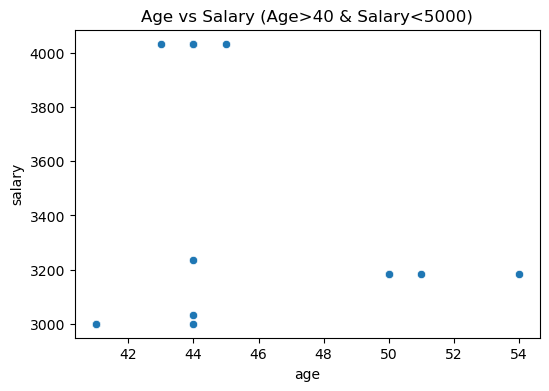

In [24]:
filtered = df[(df['age'] > 40) & (df['salary'] < 5000)]
plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='salary', data=filtered)
plt.title("Age vs Salary (Age>40 & Salary<5000)")
plt.show()

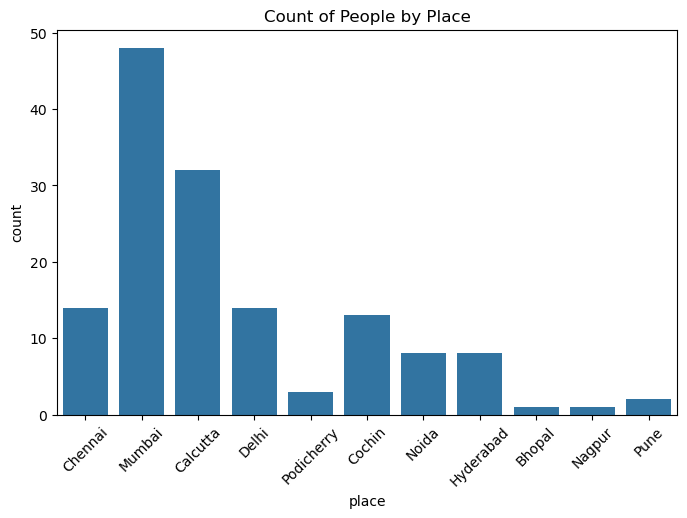

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(x='place', data=df)
plt.title("Count of People by Place")
plt.xticks(rotation=45)
plt.show()

In [31]:
from sklearn.preprocessing import LabelEncoder

label_enc = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = label_enc.fit_transform(df[col])

print("Encoded Data:", df.head())

Encoded Data:    company   age       salary  place  country  gender
0        4  20.0  5312.467742      2        0       0
1        2  30.0  5312.467742      6        0       0
2        4  35.0  2300.000000      1        0       0
3        2  40.0  3000.000000      4        0       0
4        4  23.0  4000.000000      6        0       0


In [41]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()

scaled_std = scaler_std.fit_transform(df)
scaled_minmax = scaler_minmax.fit_transform(df)

df_std = pd.DataFrame(scaled_std, columns=df.columns)
df_minmax = pd.DataFrame(scaled_minmax, columns=df.columns)

print("Standard Scaled Data:", df_std.head())
print("MinMax Scaled Data:", df_minmax.head())

Standard Scaled Data:     company       age    salary     place  country    gender
0  0.991489 -1.465777  0.010324 -0.893255      0.0 -0.534522
1 -0.239325 -0.247168  0.010324  0.750562      0.0 -0.534522
2  0.991489  0.362136 -1.266072 -1.304209      0.0 -0.534522
3 -0.239325  0.971441 -0.969479 -0.071346      0.0 -0.534522
4  0.991489 -1.100194 -0.545775  0.750562      0.0 -0.534522
MinMax Scaled Data:    company       age    salary  place  country  gender
0      0.8  0.081081  0.480650    0.2      0.0     0.0
1      0.4  0.351351  0.480650    0.6      0.0     0.0
2      0.8  0.486486  0.137817    0.1      0.0     0.0
3      0.4  0.621622  0.217480    0.4      0.0     0.0
4      0.8  0.162162  0.331285    0.6      0.0     0.0
